#### Imports

In [10]:
import tensorflow as tf

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.utils import shuffle

#### Generate Data ( noisy data arround 0 and 1)

In [12]:
def generate_xor_data(n=200, noise=0.1):
    centers = np.array([
        [0, 0], 
        [0, 1], 
        [1, 0], 
        [1, 1]  
    ])
    labels = np.array([0, 1, 1, 0])
    
    X_list = []
    y_list = []
    
    points_per_cluster = n // 4
    
    for i, center in enumerate(centers):
        cluster_points = np.random.normal(loc=center, scale=noise, size=(points_per_cluster, 2))
        
        X_list.append(cluster_points)
        y_list.append(np.full(points_per_cluster, labels[i]))
    
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y
X_xor, y_xor = generate_xor_data(n=100)

#### Create and Compile

In [13]:

model = Sequential()
model.add(Dense(units=2, input_dim=2, activation='sigmoid'))

model.add(Dense(units=1, activation='sigmoid'))

# Compile
opt = tf.keras.optimizers.Adam(learning_rate=0.1)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

#### Training

Training...
Final Accuracy: 100.00%


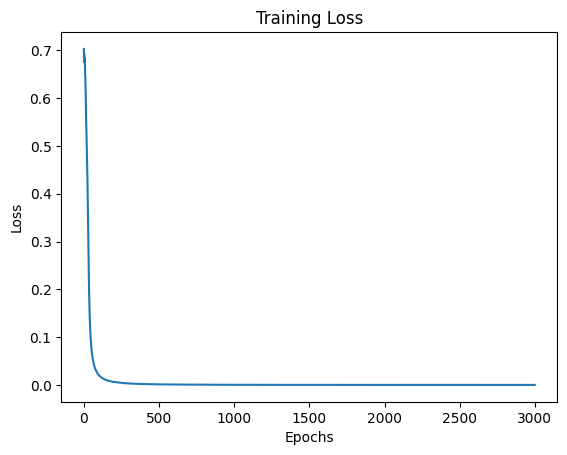

In [14]:
print("Training...")
history = model.fit(X_xor, y_xor, epochs=3000, verbose=0)

loss, acc = model.evaluate(X_xor, y_xor, verbose=0)
print(f"Final Accuracy: {acc*100:.2f}%")

# Plot Loss
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

#### Boundry

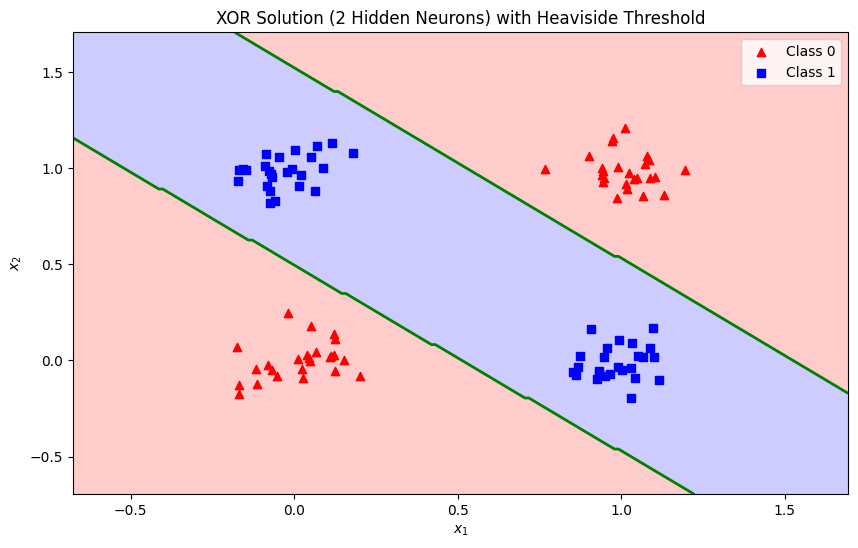

In [15]:
def plot_boundary(X, y, model):
    plt.figure(figsize=(10, 6))
    

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', marker='^', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='s', label='Class 1')
    

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict(grid, verbose=0)
    

    preds = (probs >= 0.5).astype(int).reshape(xx.shape)
    
    # Contour
    plt.contourf(xx, yy, preds, levels=[-0.1, 0.5, 1.1], alpha=0.2, colors=['red', 'blue'])
    plt.contour(xx, yy, preds, levels=[0.5], linewidths=2, colors='green')
    
    plt.title("XOR Solution (2 Hidden Neurons) with Heaviside Threshold")
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.show()

plot_boundary(X_xor, y_xor, model)